In [4]:
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import r2_score

In [5]:
df = pd.read_csv('../Data/housing.csv')

Elimina los máximos

In [6]:
df = df.query('median_house_value < 5000001')

In [7]:
import numpy as np
df['total_bedrooms'] = df.total_bedrooms.fillna(np.mean(df.total_bedrooms.mean()))

In [8]:
df = pd.get_dummies(df)

In [9]:
# df['ocean_proximity_inland']= df.ocean_proximity == 'INLAND'

## Crea un modelo de regresión lineal simple usando el ingreso y calcula su R2

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
X = df[['median_income']]
y = df['median_house_value']

model = LinearRegression().fit(X,y)
predicciones = model.predict(X)
from sklearn.metrics import r2_score

r2_score(y_pred=predicciones, y_true=y)



0.47344749180719903

## Regresion lineal usando la edad

In [12]:
X = df[['housing_median_age']]
y = df['median_house_value']

model = LinearRegression().fit(X,y)
predicciones1 = model.predict(X)
from sklearn.metrics import r2_score

r2_score(y_pred=predicciones1, y_true=y)



0.011156305266710742

## Crea un modelo de regresión lineal multiple usando las variables anteriores

In [13]:
X = df[['median_income','housing_median_age']]
y = df['median_house_value']

model = LinearRegression().fit(X,y)
predicciones2 = model.predict(X)
from sklearn.metrics import r2_score

r2_score(y_pred=predicciones2, y_true=y)



0.5091195899765226

Escribe la ecuación del modelo

In [14]:
model.intercept_

np.float64(-10189.032759083027)

In [15]:
model.coef_

array([43169.1907545 ,  1744.13444566])

$$Precio = \beta_0 + \beta_1 * x_1 + \beta_2* x_2$$

$$Precio = -10189 + 43169 * x_1 + 1744* x_2$$



### Agrega la variable de households

In [16]:
X = df.copy()
del X['median_house_value']

model = linear_model.LinearRegression().fit(X,y)



Escribe la ecuación del modelo

In [17]:
predicciones_todo = model.predict(X)

In [18]:
r2_score(y_pred=predicciones_todo, y_true=y)

0.6454747751244776

In [19]:
betas = pd.DataFrame({
    'variables': X.keys(),
    'betas': model.coef_.ravel()
})

In [20]:
betas

,variables,betas
0,longitude,-26458.289969
1,latitude,-25197.199506
2,housing_median_age,1057.863788
3,total_rooms,-4.772530
4,total_bedrooms,72.289588
5,population,-39.261842
6,households,76.940861
7,median_income,38774.913843
8,ocean_proximity_<1H OCEAN,-23475.989236
9,ocean_proximity_INLAND,-63195.665388


### Agrega todas

In [21]:
df_predicciones = pd.DataFrame({
    'predicciones_income': predicciones,
    'predicciones_age': predicciones1,
    'predicciones_income_age': predicciones2,
    'predicciones_todo': predicciones_todo,
    'y': y
})

In [22]:
df_predicciones.corr()

,predicciones_income,predicciones_age,predicciones_income_age,predicciones_todo,y
predicciones_income,1.000000,-0.119034,0.964331,0.856439,0.688075
predicciones_age,-0.119034,1.000000,0.148030,0.131468,0.105623
predicciones_income_age,0.964331,0.148030,1.000000,0.888117,0.713526
predicciones_todo,0.856439,0.131468,0.888117,1.000000,0.803414
y,0.688075,0.105623,0.713526,0.803414,1.000000


In [23]:
df_predicciones['bins_todo'] = pd.qcut(df_predicciones['predicciones_todo'], q=10, labels=False)
df_predicciones['bins_predicciones_income_age'] = pd.qcut(df_predicciones['predicciones_age'], q=10, labels=False)

In [24]:
# Bivariado todo
bivariado_todo = df_predicciones.groupby('bins_todo').mean()[['predicciones_todo', 'y']]
bivariado_income_age = df_predicciones.groupby('bins_todo').mean()[['predicciones_age', 'y']]



In [25]:
import matplotlib.pyplot as plt

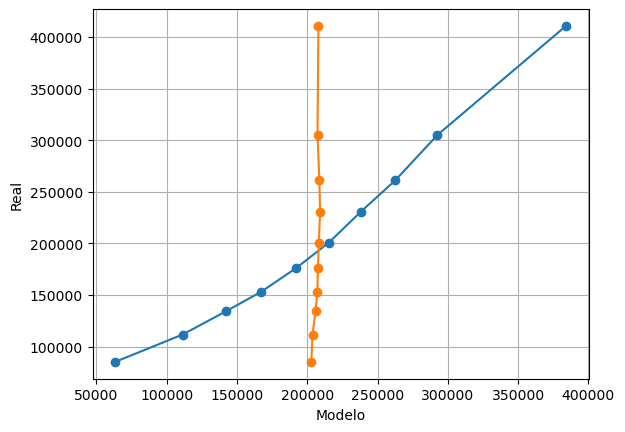

In [26]:
plt.plot(bivariado_todo.predicciones_todo, bivariado_todo.y, marker="o")
plt.plot(bivariado_income_age.predicciones_age, bivariado_income_age.y, marker="o")
plt.xlabel("Modelo")
plt.ylabel("Real")
plt.grid()

### Visualizando el modelo, calibracion